In [1]:
import os
import string
import textwrap

import dask.diagnostics
import faceted
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

import plotting

from matplotlib.patches import Patch
from pathlib import Path

In [2]:
SURFACE_TEMPERATURE = "surface_temperature"
SEA_ICE_FRACTION = "sea_ice_fraction"
LAND_FRACTION = "land_fraction"
CO2 = "global_mean_co2"
BELOW_SEA_ICE_TEMPERATURE = 273.15 - 1.8  # -1.8 Celsius
FULL_STATE = "full_state"
SCALAR = "scalar"
LONGITUDE = "grid_xt"
LATITUDE = "grid_yt"


def construct_sst(ds: xr.Dataset) -> xr.DataArray:
    is_sea_ice_free = ds[SEA_ICE_FRACTION] == 0.0
    result = ds[SURFACE_TEMPERATURE].where(is_sea_ice_free)
    result = result.fillna(BELOW_SEA_ICE_TEMPERATURE)
    result = result.rename("sst")
    return result.assign_attrs(long_name="Sea surface temperature [K]")


def compute_ocean_mean(field: xr.DataArray, land_fraction: xr.DataArray) -> xr.DataArray:
    area_weights = np.cos(np.deg2rad(land_fraction[LATITUDE]))
    is_non_land = land_fraction.isel(time=0, drop=True) == 0
    weights = area_weights.where(is_non_land).fillna(0.0)
    return field.weighted(weights).mean([LONGITUDE, LATITUDE])


def open_tape(root: str, case: str, tape: str) -> xr.Dataset:
    path = os.path.join(root, case, f"{tape}.zarr")
    return xr.open_zarr(path)


def open_tapes(root: str, cases: list[str], tape: str) -> xr.Dataset:
    datasets = {}
    for case in cases:
        datasets[case] = open_tape(root, case, tape)
    return xr.concat(datasets.values(), dim=pd.Index(datasets.keys(), name="case"))


def process_dataset(root: str, cases: list[str]) -> xr.Dataset:
    full_state = open_tapes(root, cases, FULL_STATE)
    scalar = open_tapes(root, cases, SCALAR)
    sst = construct_sst(full_state)
    ocean_mean_sst = compute_ocean_mean(sst, full_state[LAND_FRACTION])
    co2 = scalar[CO2]
    return xr.merge([ocean_mean_sst, co2])

In [ ]:
CLIMATES = ["1xCO2", "2xCO2", "3xCO2", "4xCO2"]
INITIAL_CONDITIONS = ["ic_0001", "ic_0002", "ic_0003", "ic_0004", "ic_0005"]
EQUILIBRIUM_CLIMATE_CASES = []
for climate in CLIMATES:
    for initial_condition in INITIAL_CONDITIONS:
        EQUILIBRIUM_CLIMATE_CASES.append(f"{climate}-{initial_condition}")

RANDOM_CO2_CLIMATES = ["1xCO2", "2xCO2", "4xCO2"]
RANDOM_CO2_INITIAL_CONDITIONS = ["ic_0001", "ic_0002"]
RANDOM_CO2_CASES = []
for climate in RANDOM_CO2_CLIMATES:
    for initial_condition in RANDOM_CO2_INITIAL_CONDITIONS:
        if initial_condition != "ic_0001":
            case = f"ramped-sst-{climate}-random-perturbation-{initial_condition}"
        else:
            case = f"ramped-sst-{climate}-random-perturbation"
        RANDOM_CO2_CASES.append(case)

ROOTS = {
    "AMIP": {
        "root": "gs://vcm-ml-raw-flexible-retention/2024-06-29-C96-SHiELD-AMIP/regridded-zarrs/gaussian_grid_180_by_360",
        "cases": ["ic_0001", "ic_0002"]
    },
    "equilibrium-climate": {
        "root": "gs://vcm-ml-raw-flexible-retention/2024-07-03-C96-SHiELD-SOM/regridded-zarrs/gaussian_grid_180_by_360",
        "cases": EQUILIBRIUM_CLIMATE_CASES
    },
    "random-CO2": {
        "root": "gs://vcm-ml-raw-flexible-retention/2025-08-22-C96-SHiELD/regridded-zarrs/gaussian_grid_180_by_360",
        "cases": RANDOM_CO2_CASES
    },
    "abrupt-4xCO2": {
        "root": "gs://vcm-ml-raw-flexible-retention/2024-07-03-C96-SHiELD-SOM/regridded-zarrs/gaussian_grid_180_by_360",
        "cases": ["abrupt-4xCO2"]
    },
    "AMIP-constant-CO2": {
        "root": "gs://vcm-ml-raw-flexible-retention/2025-12-16-C96-SHiELD-AMIP-constant-CO2/regridded-zarrs/gaussian_grid_180_by_360",
        "cases": ["AMIP-constant-CO2"]
    },
    "AMIP-plus-4K": {
        "root": "gs://vcm-ml-raw-flexible-retention/2025-04-28-C96-SHiELD-AMIP/regridded-zarrs/gaussian_grid_180_by_360",
        "cases": ["AMIP-p4K"]
    },
    "2pctCO2-ic_0001": {
        "root": "gs://vcm-ml-raw-flexible-retention/2024-07-03-C96-SHiELD-SOM/regridded-zarrs/gaussian_grid_180_by_360",
        "cases": ["increasing-CO2"]
    },
    "2pctCO2-ic_0002": {
        "root": "gs://vcm-ml-raw-flexible-retention/2025-03-14-C96-SHiELD-SOM/regridded-zarrs/gaussian_grid_180_by_360",
        "cases": ["increasing-CO2"]
    }
}

In [ ]:
for label, properties in ROOTS.items():
    filename = f"phase-space-statistics-{label}.nc"
    root = properties["root"]
    cases = properties["cases"]
    ds = process_dataset(root, cases)
    print(f"Writing phase-space statistics to {filename}")
    with dask.diagnostics.ProgressBar():
        ds.to_netcdf(filename)

Could not determine bucket type for bucket name vcm-ml-raw-flexible-retention: Timeout of 60.0s exceeded, last exception: 503 Getting metadata from plugin failed with error: Reauthentication is needed. Please run `gcloud auth application-default login` to reauthenticate., falling back to GCSFileSystem


In [4]:
TRAINING_DATA_WITHOUT_RANDOM_CO2 = {
    "phase-space-statistics-AMIP": {"cases": ["ic_0001", "ic_0002"], "time_slice": {"ic_0001": [slice("1979", "2008")], "ic_0002": [slice("1981-07-01", "1986-06-30"), slice("1991-07-01", "1996-06-30"), slice("2001-07-01", "2006-06-30")]}},
    "phase-space-statistics-equilibrium-climate": {"cases": ["1xCO2-ic_0001", "2xCO2-ic_0001", "4xCO2-ic_0001", "1xCO2-ic_0002", "2xCO2-ic_0002", "4xCO2-ic_0002"], "time_slice": {"1xCO2-ic_0001": [slice(None, None)], "1xCO2-ic_0002": [slice("2032-01-01", "2036-12-31")], "2xCO2-ic_0001": [slice(None, None)], "2xCO2-ic_0002": [slice("2032-01-01", "2036-12-31")], "4xCO2-ic_0001": [slice(None, None)], "4xCO2-ic_0002": [slice("2032-01-01", "2036-12-31")]}},
}
TRAINING_DATA_WITH_RANDOM_CO2 = {
    "phase-space-statistics-AMIP": {"cases": ["ic_0001"], "time_slice": slice("1979", "2008")},
    "phase-space-statistics-equilibrium-climate": {"cases": ["1xCO2-ic_0001", "2xCO2-ic_0001", "4xCO2-ic_0001"], "time_slice": slice(None, None)},
    "phase-space-statistics-random-CO2": {"cases": RANDOM_CO2_CASES, "time_slice": slice("2020-01-01T06:00:00", None)},
}

In [5]:
def load_phase_space_statistics(datasets):
    dataframes = []
    for dataset, properties in datasets.items():
        path = f"{dataset}.nc"
        cases = properties["cases"]
        time_slice = properties["time_slice"]
        if isinstance(time_slice, dict):
            sub_dataframes = []
            for case in cases:
                for sub_slice in time_slice[case]:
                    ds = xr.open_dataset(path).sel(case=case, time=sub_slice)
                    df = ds.to_dataframe()
                    sub_dataframes.append(df)
            df = pd.concat(sub_dataframes)
        else:
            ds = xr.open_dataset(path).sel(case=cases, time=time_slice)
            df = ds.to_dataframe()
        dataframes.append(df)
    return pd.concat(dataframes)

In [6]:
df_training_without_random_co2 = load_phase_space_statistics(TRAINING_DATA_WITHOUT_RANDOM_CO2)
df_training_with_random_co2 = load_phase_space_statistics(TRAINING_DATA_WITH_RANDOM_CO2)

df_2pctCO2_ic_0001 = xr.open_dataset("phase-space-statistics-2pctCO2-ic_0001.nc").sel(time=slice("2031", "2100")).to_dataframe()
df_2pctCO2_ic_0002 = xr.open_dataset("phase-space-statistics-2pctCO2-ic_0002.nc").sel(time=slice("2031", "2100")).to_dataframe()
df_2pctCO2 = pd.concat([df_2pctCO2_ic_0001, df_2pctCO2_ic_0002])
df_AMIP_constant_CO2 = xr.open_dataset("phase-space-statistics-AMIP-constant-CO2.nc").sel(time=slice("1980", "2020")).to_dataframe()
df_AMIP_p4K = xr.open_dataset("phase-space-statistics-AMIP-plus-4K.nc").sel(time=slice("1980", "2020")).to_dataframe()
df_abrupt_4xCO2 = xr.open_dataset("phase-space-statistics-abrupt-4xCO2.nc").to_dataframe()
df_3xCO2 = xr.open_dataset("phase-space-statistics-equilibrium-climate.nc").sel(case=[f"3xCO2-ic_000{i}" for i in range(1, 6)]).to_dataframe()

In [7]:
sst_bins = np.histogram_bin_edges(df_training_with_random_co2["sst"], bins=50)
co2_bins = np.exp(np.histogram_bin_edges(np.log(df_training_with_random_co2["global_mean_co2"]), bins=50))
co2_bins[0] = df_training_with_random_co2["global_mean_co2"].min()
co2_bins[-1] = df_training_with_random_co2["global_mean_co2"].max()

In [8]:
counts, *_ = np.histogram2d(df_training_without_random_co2["global_mean_co2"], df_training_without_random_co2["sst"], bins=(co2_bins, sst_bins))
np.max(counts)

np.float64(10873.0)

In [9]:
counts, *_ = np.histogram2d(df_training_with_random_co2["global_mean_co2"], df_training_with_random_co2["sst"], bins=(co2_bins, sst_bins))
np.max(counts)

np.float64(7321.0)

In [10]:
colors = sns.color_palette()
colors

[(0.33725490196078434, 0.7058823529411765, 0.9137254901960784),
 (0.9019607843137255, 0.6235294117647059, 0.0),
 (0.0, 0.6196078431372549, 0.45098039215686275),
 (0.0, 0.4470588235294118, 0.6980392156862745),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.4745098039215686, 0.6549019607843137),
 (0.9411764705882353, 0.8941176470588236, 0.25882352941176473)]

In [11]:
COLORS = {
    "2pctCO2": colors[1],
    "abrupt-4xCO2": colors[5],
    "AMIP-p4K": colors[4],
    "AMIP-constant-CO2": colors[3],
    "3xCO2": colors[2]
}

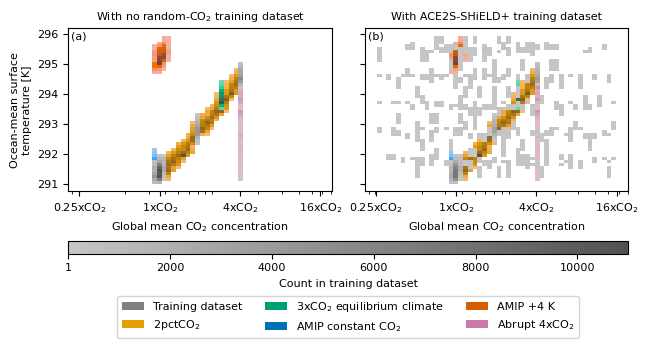

In [13]:
from matplotlib.colors import Normalize

plotting.configure_style()
fig, (ax1, ax2), cax = faceted.faceted(1, 2, width=6.5, aspect=0.618, cbar_mode="single", cbar_location="bottom", left_pad=0.65, bottom_pad=0.9)

for ax in (ax1, ax2):
    sns.histplot(ax=ax, data=df_2pctCO2, x="global_mean_co2", y="sst", bins=(co2_bins, sst_bins), color=COLORS["2pctCO2"])
    sns.histplot(ax=ax, data=df_abrupt_4xCO2, x="global_mean_co2", y="sst", bins=(co2_bins, sst_bins), color=COLORS["abrupt-4xCO2"])
    sns.histplot(ax=ax, data=df_AMIP_p4K, x="global_mean_co2", y="sst", bins=(co2_bins, sst_bins), color=COLORS["AMIP-p4K"])
    sns.histplot(ax=ax, data=df_AMIP_constant_CO2, x="global_mean_co2", y="sst", bins=(co2_bins, sst_bins), color=COLORS["AMIP-constant-CO2"])
    sns.histplot(ax=ax, data=df_3xCO2, x="global_mean_co2", y="sst", bins=(co2_bins, sst_bins), color=COLORS["3xCO2"])

norm = Normalize(vmin=1, vmax=11000)
cbar_kws = {"orientation": "horizontal", "label": "Count in training dataset", "ticks": [1, 2000, 4000, 6000, 8000, 10000]}
sns.histplot(ax=ax1, data=df_training_without_random_co2, x="global_mean_co2", y="sst", bins=(co2_bins, sst_bins), norm=norm, vmin=None, vmax=None, color="gray")
sns.histplot(ax=ax2, data=df_training_with_random_co2, x="global_mean_co2", y="sst", bins=(co2_bins, sst_bins), norm=norm, vmin=None, vmax=None, color="gray", cbar=True, cbar_ax=cax, cbar_kws=cbar_kws)

for ax, label in zip((ax1, ax2), string.ascii_lowercase):
    ax.set_xscale("log")
    ax.set_xticks(363.43 * np.array([0.25, 1, 4, 16]) / 1e6)
    ax.set_xticklabels(["0.25xCO$_2$", "1xCO$_2$", "4xCO$_2$", "16xCO$_2$"])
    ax.set_xlabel("Global mean CO$_2$ concentration")
    ax.set_ylabel("")

    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(2, -2),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
    )

ax1.set_ylabel(textwrap.fill("Ocean-mean surface temperature [K]", width=25))

patch_colors = {
    "Training dataset": "gray",
    "2pctCO$_2$": COLORS["2pctCO2"],
    "3xCO$_2$ equilibrium climate": COLORS["3xCO2"],
    "AMIP constant CO$_2$": COLORS["AMIP-constant-CO2"],
    "AMIP +4 K": COLORS["AMIP-p4K"],
    "Abrupt 4xCO$_2$": COLORS["abrupt-4xCO2"]
}

patches = [
    Patch(facecolor=color, label=label)
    for label, color in patch_colors.items()
]

central_x_position = plotting.get_central_position_between_axes((ax1, ax2), "x")
fig.legend(
    patches,
    list(patch_colors.keys()),
    loc="lower center",
    bbox_to_anchor=(central_x_position, 0.0),
    ncol=3,
    frameon=True,
)

ax1.set_title("With no random-CO$_2$ training dataset")
ax2.set_title("With ACE2S-SHiELD+ training dataset")

fig.patch.set_alpha(0.0)
fig.savefig("figure-02.png", dpi=300)
fig.savefig("figure-02.pdf")
